# Spatial Point Process — SF Crime Incidents

Models crime incidents as an **inhomogeneous Poisson process** on 2-D space.

The spatial log-intensity surface is modelled with a **Gaussian Process (RBF kernel)**,
giving a **Log-Gaussian Cox Process (LGCP)**. No time covariates are used.

**Data**: SF Police Department incident reports 2018–2025  
**Train**: 2018–2023 (6 years) | **Test**: 2024–2025 (2 years)

## 1. Setup

In [38]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import ClippedAdam
import matplotlib.pyplot as plt

pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)
print("Setup complete.")

Setup complete.


## 2. Data loading

In [39]:
DATA_PATH = '../../data/processed/incidents_2018_2025.csv'

LAT_MIN, LAT_MAX = 37.70, 37.84
LON_MIN, LON_MAX = -122.53, -122.35

df = pd.read_csv(DATA_PATH, low_memory=False)
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])
df = df.dropna(subset=['Latitude', 'Longitude'])
df = df[
    df['Latitude'].between(LAT_MIN, LAT_MAX) &
    df['Longitude'].between(LON_MIN, LON_MAX)
].copy()

# SF crime declined ~15 %/yr after 2022. Using only recent years as training
# data gives a much more accurate spatial baseline for 2024-2025 than averaging
# over the high-crime years 2018-2019.
TRAIN_YEARS_LIST = [2021, 2022, 2023]
TEST_YEARS_LIST  = [2024, 2025]
TRAIN_YEARS = len(TRAIN_YEARS_LIST)
TEST_YEARS  = len(TEST_YEARS_LIST)

df_train = df[df['Incident Datetime'].dt.year.isin(TRAIN_YEARS_LIST)].copy()
df_test  = df[df['Incident Datetime'].dt.year.isin(TEST_YEARS_LIST)].copy()

print(f"Train ({TRAIN_YEARS_LIST[0]}–{TRAIN_YEARS_LIST[-1]}): {len(df_train):,} incidents")
print(f"Test  ({TEST_YEARS_LIST[0]}–{TEST_YEARS_LIST[-1]}):  {len(df_test):,} incidents")

Train (2021–2023): 366,384 incidents
Test  (2024–2025):  194,241 incidents


## 3. Grid discretisation

We divide SF into a regular **20 × 20** grid and count incidents per cell.
Each cell has the same area, so the exposure offset is the same for all cells
and only needs to account for the length of the observation window.

In [40]:
GRID_SIZE = 20  # 20 × 20 = 400 cells

lat_edges = np.linspace(LAT_MIN, LAT_MAX, GRID_SIZE + 1)
lon_edges = np.linspace(LON_MIN, LON_MAX, GRID_SIZE + 1)
lat_mid   = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_mid   = (lon_edges[:-1] + lon_edges[1:]) / 2

# Grid centroids: shape [N_CELLS, 2] in (lat, lon) order
LON_GRID, LAT_GRID = np.meshgrid(lon_mid, lat_mid)
centroids = np.stack([LAT_GRID.ravel(), LON_GRID.ravel()], axis=1)

def assign_cell(df_in):
    lat_idx = np.clip(np.digitize(df_in['Latitude'].values,  lat_edges) - 1, 0, GRID_SIZE - 1)
    lon_idx = np.clip(np.digitize(df_in['Longitude'].values, lon_edges) - 1, 0, GRID_SIZE - 1)
    return lat_idx * GRID_SIZE + lon_idx

N_CELLS   = GRID_SIZE * GRID_SIZE
counts_tr = np.bincount(assign_cell(df_train), minlength=N_CELLS).astype(np.float32)
counts_te = np.bincount(assign_cell(df_test),  minlength=N_CELLS).astype(np.float32)

print(f"Grid: {GRID_SIZE}×{GRID_SIZE} = {N_CELLS} cells")
print(f"Train counts — mean: {counts_tr.mean():.1f}  max: {counts_tr.max():.0f}")
print(f"Test  counts — mean: {counts_te.mean():.1f}  max: {counts_te.max():.0f}")

# ── Weekly aggregation of test data ───────────────────────────────────────────
df_test_c = df_test.copy()
df_test_c['cell'] = assign_cell(df_test_c)
df_test_c['week'] = df_test_c['Incident Datetime'].dt.to_period('W')

weekly_te_df = (
    df_test_c.groupby(['week', 'cell']).size()
    .unstack(fill_value=0)
    .reindex(columns=range(N_CELLS), fill_value=0)
)
weekly_te_arr = weekly_te_df.values.astype(np.float32)   # [n_weeks, N_CELLS]
N_WEEKS_TE   = len(weekly_te_df)

print(f"Weekly test matrix: {N_WEEKS_TE} weeks × {N_CELLS} cells")
print(f"Mean per cell per week: {weekly_te_arr.mean():.2f}   "
      f"Max: {weekly_te_arr.max():.0f}")

Grid: 20×20 = 400 cells
Train counts — mean: 916.0  max: 19352
Test  counts — mean: 485.6  max: 13308
Weekly test matrix: 105 weeks × 400 cells
Mean per cell per week: 4.62   Max: 216


In [41]:
# Helper used in evaluation cell
def counts_for_years(years):
    sub = df[df['Incident Datetime'].dt.year.isin(years)]
    lat_idx = np.clip(np.digitize(sub['Latitude'].values, lat_edges)-1, 0, GRID_SIZE-1)
    lon_idx = np.clip(np.digitize(sub['Longitude'].values, lon_edges)-1, 0, GRID_SIZE-1)
    cells = lat_idx * GRID_SIZE + lon_idx
    return np.bincount(cells, minlength=N_CELLS).astype(float)

## 4. Exploratory data analysis

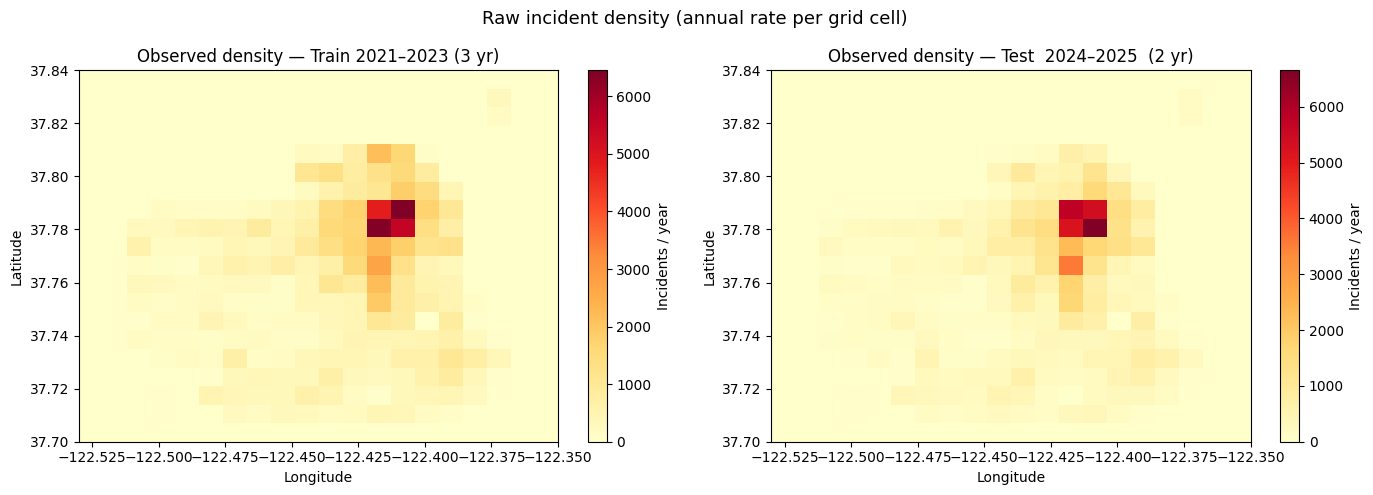

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]

for ax, counts, n_years, label in [
    (axes[0], counts_tr, TRAIN_YEARS, f"Train {TRAIN_YEARS_LIST[0]}–{TRAIN_YEARS_LIST[-1]} ({TRAIN_YEARS} yr)"),
    (axes[1], counts_te, TEST_YEARS,  f"Test  {TEST_YEARS_LIST[0]}–{TEST_YEARS_LIST[-1]}  ({TEST_YEARS} yr)"),
]:
    im = ax.imshow(counts.reshape(GRID_SIZE, GRID_SIZE) / n_years,
                   origin="lower", cmap="YlOrRd", extent=extent, aspect="auto")
    plt.colorbar(im, ax=ax, label="Incidents / year")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"Observed density — {label}")

plt.suptitle("Raw incident density (annual rate per grid cell)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Models

We compare two formulations of the inhomogeneous Poisson process on the grid.

### M1 — Homogeneous Poisson Process (spatial null model)

$$
\log\lambda \sim \mathcal{N}(0, 3)
\qquad
N_c \sim \operatorname{Poisson}(e^{\log\lambda} \cdot T) \quad \forall\, c
$$

All cells share a single global rate $\lambda$. This is the **null hypothesis**:
crime is spatially uniform. We expect this to fit poorly.

---

### M2 — Inhomogeneous Poisson Process (main model)

$$
\mu \sim \mathcal{N}(0,3), \quad \sigma \sim \operatorname{HalfNormal}(1.5)
$$
$$
\log\lambda_c \sim \mathcal{N}(\mu,\,\sigma^2) \quad \forall\, c
$$
$$
N_c \sim \operatorname{Poisson}(\lambda_c \cdot T)
$$

Each cell $c$ has its own spatial intensity $\lambda_c$, drawn from a shared
log-normal prior (partial pooling / Bayesian shrinkage).  
This is the **Poisson-lognormal** model — the discrete-grid realisation of a
Log-Gaussian Cox Process (LGCP).

- $\mu$ controls the global crime level
- $\sigma$ controls how much spatial heterogeneity the data supports
- Shrinkage toward $\mu$ prevents over-fitting for cells with few observations

We compare models via the **ELBO** (Evidence Lower BOund):
a higher ELBO means a better fit to the data under the variational posterior.

In [43]:
X    = torch.tensor(
    np.stack([(centroids[:,0]-LAT_MIN)/(LAT_MAX-LAT_MIN),
              (centroids[:,1]-LON_MIN)/(LON_MAX-LON_MIN)], axis=1),
    dtype=torch.float32)

y_tr = torch.tensor(counts_tr, dtype=torch.float32)
y_te = torch.tensor(counts_te, dtype=torch.float32)

log_exp_tr = torch.log(torch.tensor(float(TRAIN_YEARS)))
log_exp_te = torch.log(torch.tensor(float(TEST_YEARS)))


# ── M1: Homogeneous Poisson Process ───────────────────────────────────────────
def model_homogeneous(log_exposure, counts=None):
    """Spatial null model: one rate for all cells."""
    log_rate = pyro.sample("log_rate_global", dist.Normal(0., 3.))
    rate = torch.exp(log_rate + log_exposure)
    with pyro.plate("cells", N_CELLS):
        pyro.sample("y", dist.Poisson(rate * torch.ones(N_CELLS)), obs=counts)


# ── M2: Inhomogeneous Poisson Process (Poisson-lognormal) ─────────────────────
def model_lgcp(log_exposure, counts=None):
    """Main model: per-cell log-rates with partial pooling."""
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(mu, sigma))
        rate = torch.exp(log_rate + log_exposure)
        pyro.sample("y", dist.Poisson(rate), obs=counts)


print("M1 (homogeneous) and M2 (inhomogeneous) defined.")

M1 (homogeneous) and M2 (inhomogeneous) defined.


## 6. Inference — SVI

We use **stochastic variational inference** with an `AutoDiagonalNormal` guide
(mean-field approximation) and `ClippedAdam` to stabilise gradients through
the `exp()` Poisson link.

In [44]:
import tempfile

def save_guide(guide):
    _, guide._param_file = tempfile.mkstemp(suffix=".pth")
    pyro.get_param_store().save(guide._param_file)

def restore_guide(guide):
    pyro.clear_param_store()
    state = torch.load(guide._param_file, weights_only=False)
    pyro.get_param_store().set_state(state)

# Train M1
print("Training M1 (homogeneous, 3 000 steps)...")
pyro.set_rng_seed(42); pyro.clear_param_store()
guide_1 = AutoDiagonalNormal(model_homogeneous)
svi_1   = SVI(model_homogeneous, guide_1, ClippedAdam({"lr": 0.01}), loss=Trace_ELBO())
losses_1 = []
for step in range(3_000):
    losses_1.append(svi_1.step(log_exp_tr, y_tr))
save_guide(guide_1)
elbo_1 = -float(np.mean(losses_1[-200:]))
print(f"  M1 ELBO = {elbo_1:,.0f}")

# Train M2
print("Training M2 (hierarchical, 10 000 steps)...")
pyro.set_rng_seed(42); pyro.clear_param_store()
guide_2 = AutoDiagonalNormal(model_lgcp)
svi_2   = SVI(model_lgcp, guide_2, ClippedAdam({"lr": 0.01}), loss=Trace_ELBO())
losses_2 = []
for step in range(10_000):
    loss = svi_2.step(log_exp_tr, y_tr)
    losses_2.append(loss)
    if step % 2_000 == 0:
        print(f"  step {step:5d}  ELBO = {-loss:,.0f}")
save_guide(guide_2)
elbo_2 = -float(np.mean(losses_2[-200:]))
print(f"  M2 ELBO = {elbo_2:,.0f}")

delta = elbo_2 - elbo_1
print(f"\nDelta ELBO = M2 - M1 = {delta:+,.0f} nats")

guide  = guide_2
losses = losses_2

Training M1 (homogeneous, 3 000 steps)...
  M1 ELBO = -482,773
Training M2 (hierarchical, 10 000 steps)...
  step     0  ELBO = -1,971,684
  step  2000  ELBO = -2,316
  step  4000  ELBO = -2,294
  step  6000  ELBO = -2,261
  step  8000  ELBO = -2,281
  M2 ELBO = -2,311

Delta ELBO = M2 - M1 = +480,462 nats


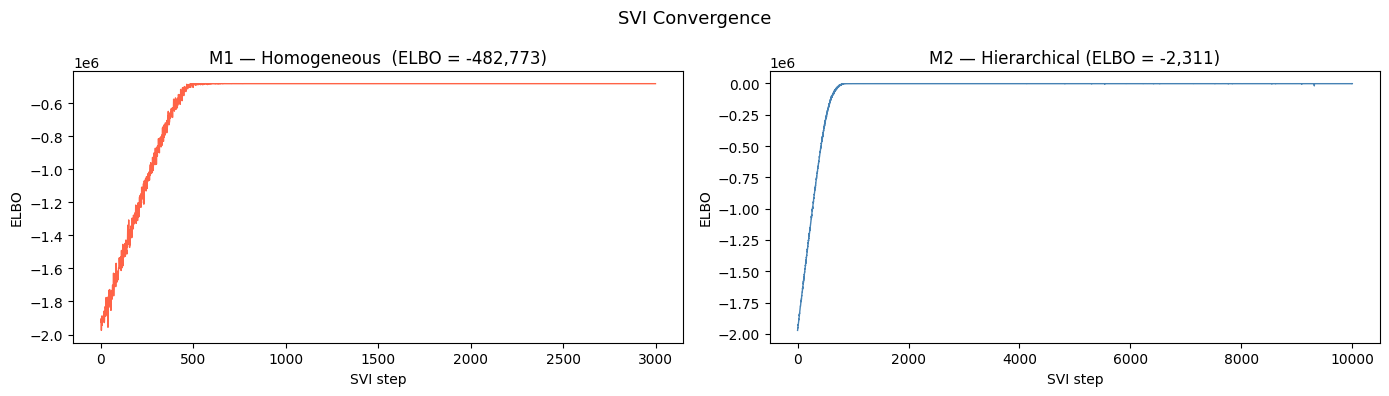

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, lss, title, col in [
    (axes[0], losses_1, f"M1 — Homogeneous  (ELBO = {elbo_1:,.0f})", "tomato"),
    (axes[1], losses_2, f"M2 — Hierarchical (ELBO = {elbo_2:,.0f})", "steelblue"),
]:
    ax.plot([-l for l in lss], color=col, lw=1)
    ax.set_xlabel("SVI step"); ax.set_ylabel("ELBO")
    ax.set_title(title)

plt.suptitle("SVI Convergence", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Posterior: estimated intensity surface

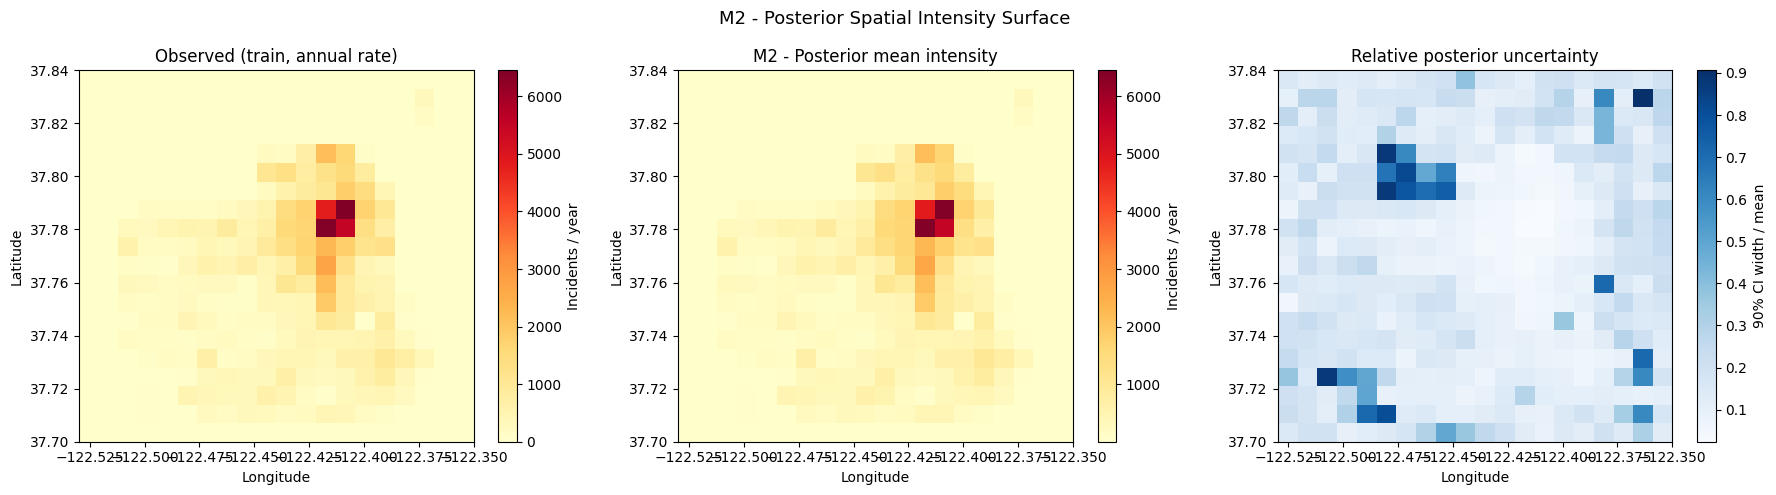

In [46]:
restore_guide(guide_2)
posterior = Predictive(model_lgcp, guide=guide_2, num_samples=500,
                       return_sites=["log_rate"])(log_exp_tr)

log_rate_s = posterior["log_rate"]
lam_s      = torch.exp(log_rate_s)
lam_mean   = lam_s.mean(0).detach().numpy()
lam_lo     = lam_s.quantile(0.05, dim=0).detach().numpy()
lam_hi     = lam_s.quantile(0.95, dim=0).detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
kw = dict(origin="lower", extent=extent, aspect="auto")

vmax = max((counts_tr / TRAIN_YEARS).max(), lam_mean.max())
im0 = axes[0].imshow((counts_tr / TRAIN_YEARS).reshape(GRID_SIZE, GRID_SIZE),
                     cmap="YlOrRd", vmax=vmax, **kw)
plt.colorbar(im0, ax=axes[0], label="Incidents / year")
axes[0].set_title("Observed (train, annual rate)")

im1 = axes[1].imshow(lam_mean.reshape(GRID_SIZE, GRID_SIZE),
                     cmap="YlOrRd", vmax=vmax, **kw)
plt.colorbar(im1, ax=axes[1], label="Incidents / year")
axes[1].set_title("M2 - Posterior mean intensity")

rel_ci = ((lam_hi - lam_lo) / (lam_mean + 1)).reshape(GRID_SIZE, GRID_SIZE)
im2 = axes[2].imshow(rel_ci, cmap="Blues", **kw)
plt.colorbar(im2, ax=axes[2], label="90% CI width / mean")
axes[2].set_title("Relative posterior uncertainty")

for ax in axes:
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.suptitle("M2 - Posterior Spatial Intensity Surface", fontsize=13)
plt.tight_layout()
plt.show()

Rank  District                Lat        Lon     λ (yr)  90% CI
──────────────────────────────────────────────────────────────────────
  1    Central             37.7875  -122.4085     6383.3  [6309.5, 6461.7]
  2    Tenderloin          37.7805  -122.4175     6377.0  [6298.0, 6455.6]
  3    Tenderloin          37.7805  -122.4085     5498.9  [5429.7, 5569.1]
  4    Central             37.7875  -122.4175     4817.2  [4753.3, 4889.5]
  5    Mission             37.7665  -122.4175     2662.0  [2613.7, 2707.4]
  6    Southern            37.7735  -122.4175     2288.1  [2244.9, 2337.4]
  7    Central             37.8085  -122.4175     2158.7  [2121.4, 2198.5]
  8    Mission             37.7595  -122.4175     2155.9  [2107.1, 2205.3]
  9    Mission             37.7525  -122.4175     1909.6  [1866.1, 1952.7]
  10   Central             37.7945  -122.4085     1829.8  [1792.2, 1870.9]


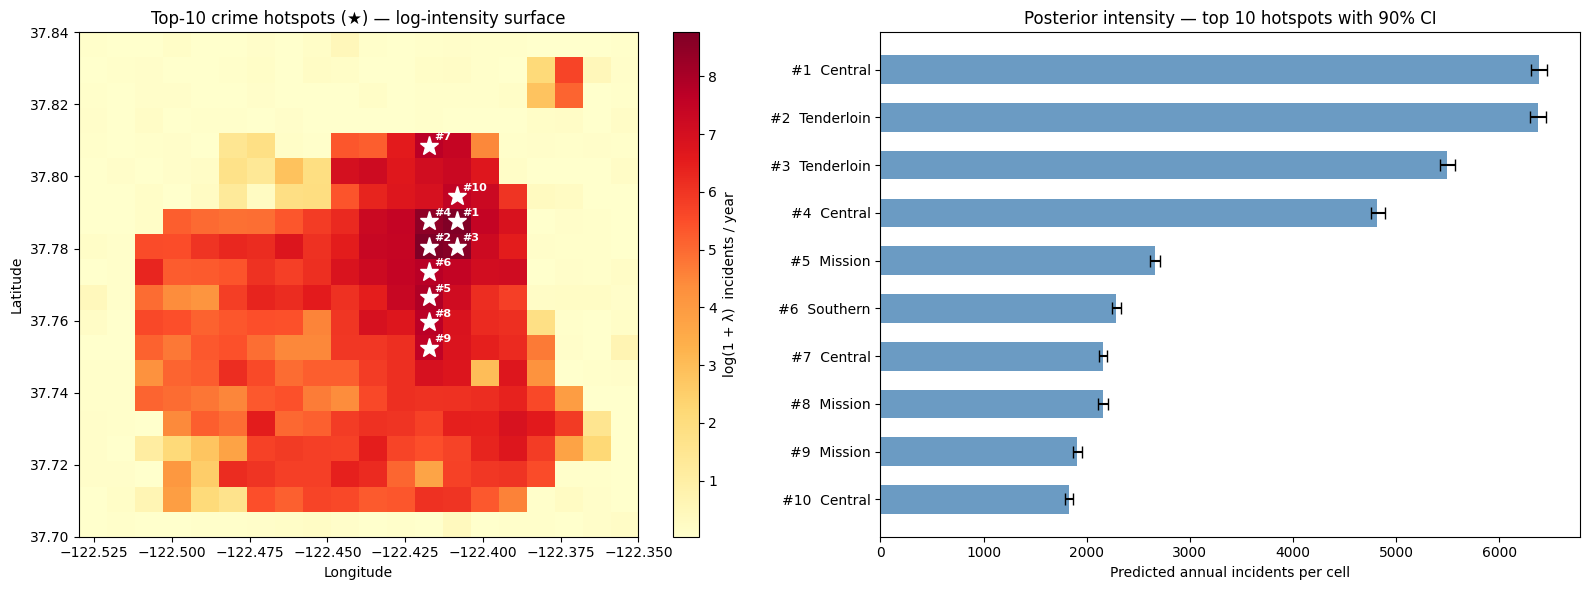

In [47]:
restore_guide(guide_2)
# ── Label each cell by its dominant police district ───────────────────────────
df_tr_c = df_train.copy()
df_tr_c["cell"] = assign_cell(df_tr_c)
cell_district = (
    df_tr_c[df_tr_c["Police District"].notna()]
    .groupby("cell")["Police District"]
    .agg(lambda x: x.mode().iloc[0])
    .reindex(range(N_CELLS), fill_value="Unknown")
)

# ── Top-10 hotspot cells ───────────────────────────────────────────────────────
K = 10
top_idx    = np.argsort(lam_mean)[::-1][:K]
top_lam    = lam_mean[top_idx]
top_lo     = lam_lo[top_idx]
top_hi     = lam_hi[top_idx]
top_dist   = [cell_district.iloc[i] for i in top_idx]
top_lats   = centroids[top_idx, 0]
top_lons   = centroids[top_idx, 1]

print(f"{'Rank':<5} {'District':<18} {'Lat':>8} {'Lon':>10} {'λ (yr)':>10}  90% CI")
print("─" * 70)
for r, (i, lam, lo, hi, dn, lat, lon) in enumerate(
        zip(top_idx, top_lam, top_lo, top_hi, top_dist, top_lats, top_lons)):
    print(f"  {r+1:<3}  {dn:<18} {lat:8.4f} {lon:10.4f} {lam:10.1f}  [{lo:.1f}, {hi:.1f}]")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]

# Log-intensity map with hotspot stars
im = axes[0].imshow(np.log1p(lam_mean).reshape(GRID_SIZE, GRID_SIZE),
                    cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
plt.colorbar(im, ax=axes[0], label="log(1 + λ)  incidents / year")
for r, (lat, lon) in enumerate(zip(top_lats, top_lons)):
    axes[0].plot(lon, lat, "w*", ms=14, zorder=5)
    axes[0].annotate(f"#{r+1}", (lon, lat), xytext=(4, 4),
                     textcoords="offset points",
                     color="white", fontsize=8, fontweight="bold")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_title("Top-10 crime hotspots (★) — log-intensity surface")

# Horizontal bar chart with 90 % CI
y_pos   = np.arange(K)
labels  = [f"#{r+1}  {d}" for r, d in enumerate(top_dist)]
xerr_lo = top_lam - top_lo
xerr_hi = top_hi  - top_lam
axes[1].barh(y_pos[::-1], top_lam, xerr=[xerr_lo, xerr_hi],
             color="steelblue", alpha=0.8, capsize=4, height=0.6)
axes[1].set_yticks(y_pos[::-1])
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Predicted annual incidents per cell")
axes[1].set_title("Posterior intensity — top 10 hotspots with 90% CI")

plt.tight_layout()
plt.show()

## 8. Test-set evaluation

We scale the per-year posterior mean by `TEST_YEARS` to get predicted counts
for the 2024–2025 window, then compare to observed test counts.

Metric                                         MAE     RMSE
──────────────────────────────────────────────────────────
Weekly / cell — model  (primary)             2.228    5.403
Weekly / cell — naive baseline               2.234    5.420
Weekly / cell — Poisson oracle floor         1.189

2-yr total / cell — model                    159.3    391.5
2-yr total / cell — naive baseline           160.1    393.9

Mean incidents per cell per week: 4.62


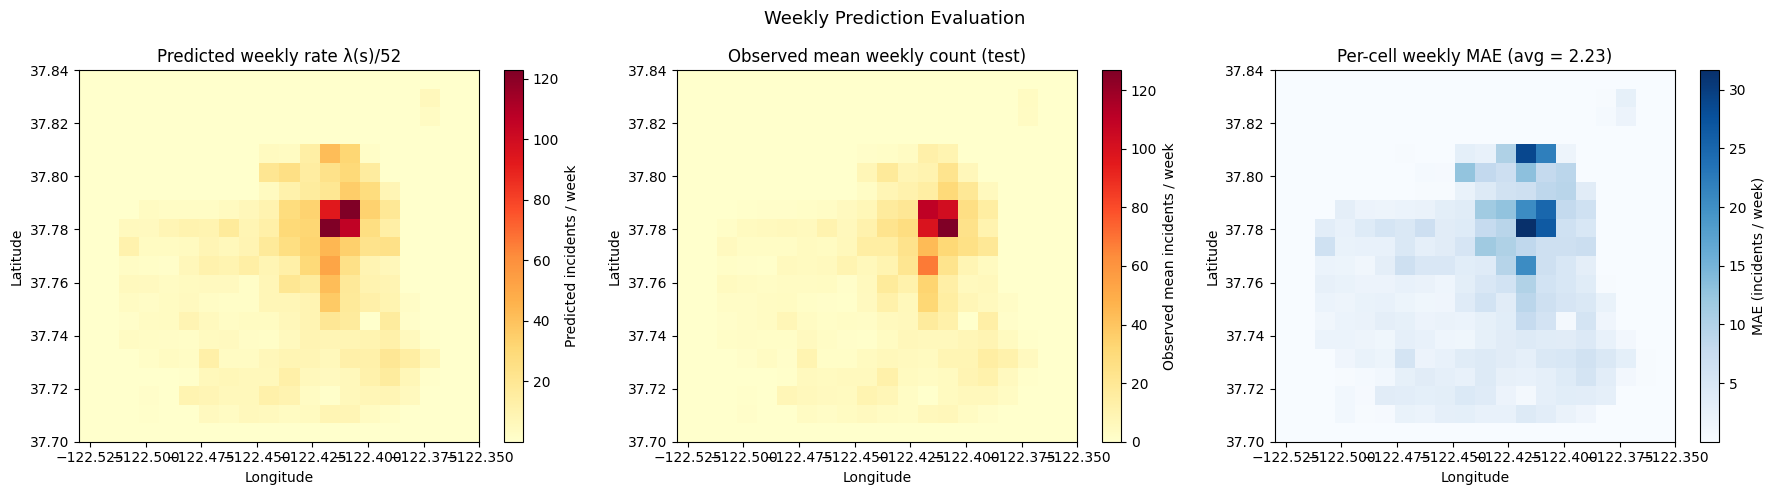

In [48]:
def metrics(y_true, y_pred):
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return mae, rmse

# ── Weekly predictions ────────────────────────────────────────────────────────
# λ_c is the annual rate per cell.  Scale to one-week expected count:
pred_weekly_c  = lam_mean / 52                                     # [N_CELLS]
pred_weekly_mat = np.tile(pred_weekly_c, (N_WEEKS_TE, 1))          # [n_weeks, N_CELLS]
naive_weekly_c  = (counts_tr / TRAIN_YEARS) / 52
naive_weekly_mat = np.tile(naive_weekly_c, (N_WEEKS_TE, 1))

mae_w,  rmse_w  = metrics(weekly_te_arr, pred_weekly_mat)
mae_wn, rmse_wn = metrics(weekly_te_arr, naive_weekly_mat)

# ── 2-year total predictions (for reference) ──────────────────────────────────
pred_te_total = lam_mean * TEST_YEARS
mae_t,  rmse_t  = metrics(counts_te, pred_te_total)
mae_tn, rmse_tn = metrics(counts_te, counts_tr / TRAIN_YEARS * TEST_YEARS)

oracle_w = float(np.mean(0.8 * np.sqrt(pred_weekly_c + 1e-3)))   # Poisson floor

print(f"{'Metric':<42} {'MAE':>7}  {'RMSE':>7}")
print("─" * 58)
print(f"{'Weekly / cell — model  (primary)':<42} {mae_w:7.3f}  {rmse_w:7.3f}")
print(f"{'Weekly / cell — naive baseline':<42} {mae_wn:7.3f}  {rmse_wn:7.3f}")
print(f"{'Weekly / cell — Poisson oracle floor':<42} {oracle_w:7.3f}")
print()
print(f"{'2-yr total / cell — model':<42} {mae_t:7.1f}  {rmse_t:7.1f}")
print(f"{'2-yr total / cell — naive baseline':<42} {mae_tn:7.1f}  {rmse_tn:7.1f}")
print()
print(f"Mean incidents per cell per week: {weekly_te_arr.mean():.2f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
kw = dict(origin="lower", extent=extent, aspect="auto")

# Predicted weekly rate surface
im0 = axes[0].imshow(pred_weekly_c.reshape(GRID_SIZE, GRID_SIZE),
                     cmap="YlOrRd", **kw)
plt.colorbar(im0, ax=axes[0], label="Predicted incidents / week")
axes[0].set_title("Predicted weekly rate λ(s)/52")

# Observed mean weekly count per cell
obs_mean_weekly = weekly_te_arr.mean(0).reshape(GRID_SIZE, GRID_SIZE)
im1 = axes[1].imshow(obs_mean_weekly, cmap="YlOrRd", **kw)
plt.colorbar(im1, ax=axes[1], label="Observed mean incidents / week")
axes[1].set_title("Observed mean weekly count (test)")

# Per-cell weekly MAE
cell_mae = np.mean(np.abs(weekly_te_arr - pred_weekly_mat), axis=0).reshape(GRID_SIZE, GRID_SIZE)
im2 = axes[2].imshow(cell_mae, cmap="Blues", **kw)
plt.colorbar(im2, ax=axes[2], label="MAE (incidents / week)")
axes[2].set_title(f"Per-cell weekly MAE (avg = {mae_w:.2f})")

for ax in axes:
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

plt.suptitle("Weekly Prediction Evaluation", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Posterior predictive check

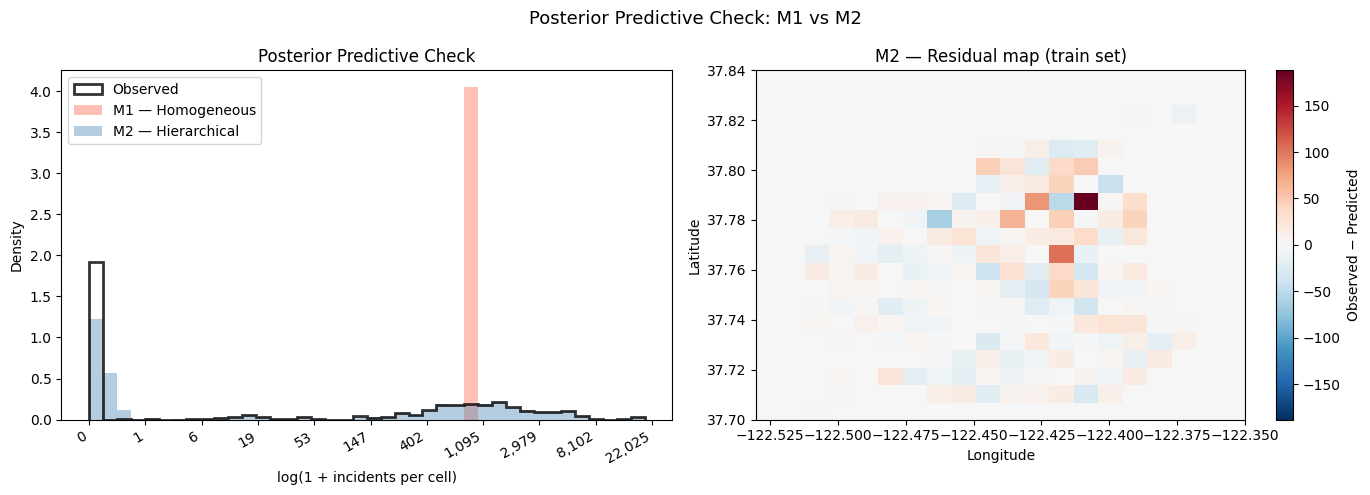

In [49]:
restore_guide(guide_1)
ppc_1 = Predictive(model_homogeneous, guide=guide_1, num_samples=500,
                   return_sites=["y"])(log_exp_tr)

restore_guide(guide_2)
ppc_2 = Predictive(model_lgcp, guide=guide_2, num_samples=500,
                   return_sites=["y"])(log_exp_tr)

y_pp_1 = ppc_1["y"].float().mean(0).detach().numpy()
y_pp_2 = ppc_2["y"].float().mean(0).detach().numpy()

# log(1+x) transform — standard for heavy-tailed count data.
# Raw scale hides the observed distribution because M1's spike is 60x taller.
obs_log  = np.log1p(counts_tr)
pp1_log  = np.log1p(y_pp_1)
pp2_log  = np.log1p(y_pp_2)
bins     = np.linspace(0, max(obs_log.max(), pp1_log.max(), pp2_log.max()), 41)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(obs_log, bins=bins, density=True, alpha=0.8,
        color="black", histtype="step", lw=2, label="Observed")
ax.hist(pp1_log, bins=bins, density=True, alpha=0.4,
        color="tomato",    label="M1 — Homogeneous")
ax.hist(pp2_log, bins=bins, density=True, alpha=0.4,
        color="steelblue", label="M2 — Hierarchical")
ax.set_xlabel("log(1 + incidents per cell)")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive Check")
ax.legend()

# Add readable x-tick labels showing original scale
ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(np.expm1(t)):,}" for t in ticks], rotation=30, ha="right")

residuals = (counts_tr - y_pp_2).reshape(GRID_SIZE, GRID_SIZE)
vmax_r = np.abs(residuals).max()
im = axes[1].imshow(residuals, origin="lower", cmap="RdBu_r",
                    vmin=-vmax_r, vmax=vmax_r,
                    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
plt.colorbar(im, ax=axes[1], label="Observed − Predicted")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].set_title("M2 — Residual map (train set)")

plt.suptitle("Posterior Predictive Check: M1 vs M2", fontsize=13)
plt.tight_layout()
display(fig)
plt.close()